In [1]:
import pickle
import os
import pandas as pd
from uncmoo.pred_utils import DockingScorePredictor

def extract_score(target_file, cache_dict, target_columns, scaler_dict):
    with open(target_file, "r") as g:
        data = g.readlines()
    smiles_list = [line.split(", ")[1] for line in data]
    predicted_fitness = [float(line.strip().split(", ")[2]) for line in data]
    scores = [list(cache_dict[smiles]) for smiles in smiles_list]
    df = pd.DataFrame(scores, columns=target_columns)
    df["predicted_fitness"] = predicted_fitness
    scaler_score_list = []
    for i, row in df.iterrows():
        score = 0
        for target in df.columns:
            if target == "predicted_fitness":
                break
            mean, std = scaler_dict[target]
            score += (row[target] - mean) / std * (-1)
        scaler_score_list.append(score)
    df['scaler score'] = scaler_score_list
    return df

parent_dir = "RESULTS/docking"
sub_dir_name = ["janus_scaler", "janus_uncertainty"]#, "janus_uncertainty_tight"]
target_columns = ["1syh score", "4lde score", "6y2f score"]
score_columns = ["1syh score", "4lde score", "6y2f score", "scaler score", "predicted_fitness"]
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
num_fold = 10

with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)

benchmark_dict = {}
for sub_dir in sub_dir_name:
    real_dir = os.path.join(parent_dir, sub_dir)
    sub_data = pd.DataFrame()
    for fold in range(1, num_fold+1):
        target_file = os.path.join(real_dir+"_{}".format(fold), "generation_all_best.txt")
        df = extract_score(target_file, cache_dict, target_columns, scaler_dict)
        rename_dict = {score: score+"_{}".format(fold) for score in score_columns}
        df = df.rename(columns=rename_dict)
        sub_data = pd.concat([sub_data, df], axis=1)
    benchmark_dict.update({sub_dir: sub_data})
    

/home/lungyi/anaconda3/envs/uncmoo2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# benchmark_dict["janus_scaler"].to_csv("a.csv")
# benchmark_dict["janus_scaler"][pred_fitness_columns].mean(axis=1)
# # process_lines(benchmark_dict["janus_scaler"], pred_fitness_columns)

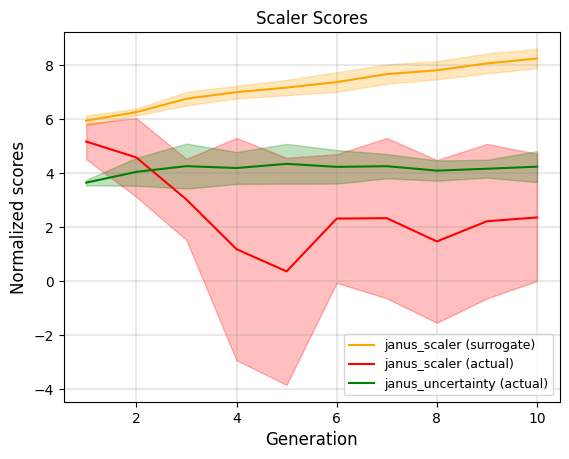

In [3]:
import matplotlib.pyplot as plt
import numpy as np

"""  Basic plot setting  """
color_dict = {"janus_scaler":"red", "janus_uncertainty": "green", "janus_uncertainty_tight": "blue", "predicted_fitness":"orange"}
marker_dict = {"1syh score": "*", "4lde score": "s", "6y2f score":"x"}
alpha_span = 0.25
center_linewidth = 0.75
label_fontsize = 12
legend_fontsize = 9
save_dir = "docs/plot_iteration"

os.makedirs(save_dir, exist_ok=True)

def process_lines(data, target_columns):
    means = data[target_columns].mean(axis=1)
    stds = data[target_columns].std(axis=1)
    return means, stds



# plot scaler scores
scaler_columns = ["scaler score_{}".format(fold) for fold in range(1, num_fold+1)]
x = [i for i in range(1, 11)]

plt.figure(dpi=100)
for sub_dir in sub_dir_name:
    data = benchmark_dict[sub_dir]
    if sub_dir == "janus_scaler":
        pred_fitness_columns = ["predicted_fitness_{}".format(fold) for fold in range(1, num_fold+1)]
        means, stds = process_lines(data, pred_fitness_columns)
        plt.plot(x, means, color=color_dict["predicted_fitness"], label=sub_dir+" (surrogate)", linewidth=center_linewidth*2)
        positive = means + stds * 1.96 / np.sqrt(num_fold)
        negative = means - stds * 1.96 / np.sqrt(num_fold)
        plt.plot(x, positive, color=color_dict["predicted_fitness"], alpha=alpha_span, linewidth=0.1)
        plt.plot(x, negative, color=color_dict["predicted_fitness"], alpha=alpha_span, linewidth=0.1)
        plt.fill_between(x,positive,negative, color=color_dict["predicted_fitness"], alpha=alpha_span)


    
    means, stds = process_lines(data, scaler_columns)
    plt.plot(x, means, color=color_dict[sub_dir], label=sub_dir+" (actual)", linewidth=center_linewidth*2)
    positive = means + stds * 1.96 / np.sqrt(num_fold)
    negative = means - stds * 1.96 / np.sqrt(num_fold)
    plt.plot(x, positive, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.1)
    plt.plot(x, negative, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.1)
    plt.fill_between(x,positive,negative, color=color_dict[sub_dir], alpha=alpha_span)
    plt.grid(color = 'gray', linestyle = '-', linewidth = 0.25)

plt.title("Scaler Scores",fontsize=label_fontsize)
# plt.text(0.15,0.9,"AUCE "+str(np.round(auce,4)))
plt.legend(fontsize=legend_fontsize)
plt.xlabel("Generation", fontsize=label_fontsize)
plt.ylabel("Normalized scores", fontsize=label_fontsize)
# print(system, auce)
plt.savefig(os.path.join(save_dir, "total_docking_scores"+".svg"), format='svg')
    

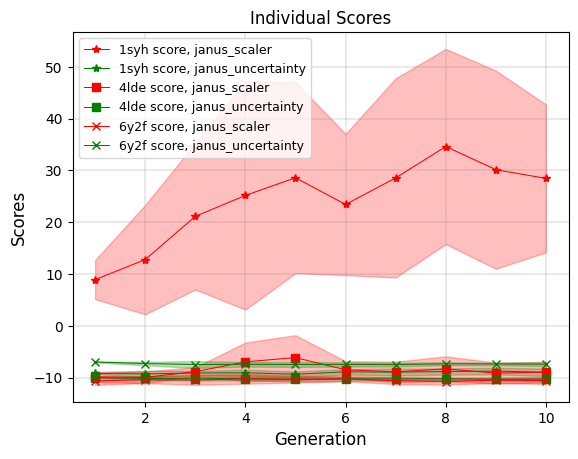

In [13]:
# plot individual scores
def normalize(x, mu, std):
    return (x - mu) / std

x = [i for i in range(1, 11)]
plt.figure(dpi=100)
for target in target_columns:
    scaler_columns = [target + "_{}".format(fold) for fold in range(1, num_fold+1)]

    for sub_dir in sub_dir_name:
        data = benchmark_dict[sub_dir]
        means, stds = process_lines(data, scaler_columns)

        
        positive = means + stds * 1.96 / np.sqrt(num_fold)
        negative = means - stds * 1.96 / np.sqrt(num_fold)

        # # normalize
        # mu, std = scaler_dict[target]
        # means = normalize(means, mu, std)
        # positive = normalize(positive, mu, std)
        # negative = normalize(negative, mu, std)

        plt.plot(x, means, color=color_dict[sub_dir], label=target+", "+sub_dir, marker=marker_dict[target], linewidth=center_linewidth)
        plt.plot(x, positive, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.01)
        plt.plot(x, negative, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.01)
        plt.fill_between(x,positive,negative, color=color_dict[sub_dir], alpha=alpha_span)
        plt.grid(color = 'gray', linestyle = '-', linewidth = 0.25)

plt.title("Individual Scores", fontsize=label_fontsize)
plt.legend(fontsize=legend_fontsize, loc="upper left")
plt.xlabel("Generation", fontsize=label_fontsize)
plt.ylabel("Scores", fontsize=label_fontsize)
plt.savefig(os.path.join(save_dir, "separate_docking_scores"+".svg"), format='svg')
